In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import src.assumptions as A
from src import (
    demand_model,
    matplotlib_style,  # noqa: F401
    power_system,
    supply_model,
)
from src.demand_model import DemandMode
from src.units import Units as U

# storage model plots

In [ ]:
# Seasonal Demand Mode
renewable_capacity = 400
demand_mode = DemandMode.SEASONAL

A.EnergyDemand2050 = A.CB7EnergyDemand2050
demand_df = demand_model.predicted_demand(mode=demand_mode, average_year=False)
df = supply_model.get_net_supply(demand_df).reset_index()

model = power_system.PowerSystem(
    renewable_capacity=renewable_capacity * U.GW,
    hydrogen_storage_capacity=50 * U.TWh,
    electrolyser_power=A.HydrogenStorage.Electrolysis.Power,
    dac_capacity=2 * U.GW,
    only_dac_if_hydrogen_storage_full=False,
    medium_storage_capacity=A.MediumTermStorage.Capacity,
    medium_storage_power=A.MediumTermStorage.Power,
)
sim_df = model.run_simulation(df)
results = model.analyze_simulation_results(sim_df)
model.plot_simulation_results(sim_df, results, demand_mode)

Cannot plot results: simulation failed for seasonal demand scenario


In [18]:
# HDD Demand Mode
renewable_capacity = 400
demand_mode = DemandMode.HDD

A.EnergyDemand2050 = A.CB7EnergyDemand2050
demand_df = demand_model.predicted_demand(mode=demand_mode, average_year=False)
df = supply_model.get_net_supply(demand_df).reset_index()

model = power_system.PowerSystem(
    renewable_capacity=renewable_capacity * U.GW,
    hydrogen_storage_capacity=A.HydrogenStorage.CavernStorage.Capacity,
    electrolyser_power=A.HydrogenStorage.Electrolysis.Power,
    dac_capacity=A.DAC.Capacity,
    only_dac_if_hydrogen_storage_full=False,
    medium_storage_capacity=A.MediumTermStorage.Capacity,
    medium_storage_power=A.MediumTermStorage.Power,
)
sim_df = model.run_simulation(df)
results = model.analyze_simulation_results(sim_df)
model.plot_simulation_results(sim_df, results, demand_mode)

Cannot plot results: simulation failed for hdd demand scenario


# surface plots


In [5]:
demand_mode = DemandMode.CB7

# A.EnergyDemand2050 = 575 * U.TWh
# A.EnergySystemLosses = 0
A.EnergyDemand2050 = A.CB7EnergyDemand2050
CONTINGENCY_MIN_STORAGE = 10 * U.TWh
renewable_capacities = range(200, 410, 10)
electrolyser_powers = range(10, 110, 10)
max_storage = range(10, 100, 10)
Z = np.zeros((len(renewable_capacities), len(electrolyser_powers))) * np.nan
xyzs = []


demand_df = demand_model.predicted_demand(mode=demand_mode, average_year=False)
df = supply_model.get_net_supply(demand_df).reset_index()

total_combinations = len(renewable_capacities) * len(electrolyser_powers) * len(max_storage)

for renewable_capacity in renewable_capacities:
    for electrolyser_power in electrolyser_powers:
        for storage in max_storage:
            model = power_system.PowerSystem(
                renewable_capacity=renewable_capacity * U.GW,
                hydrogen_storage_capacity=storage * U.TWh,
                electrolyser_power=electrolyser_power * U.GW,
                dac_capacity=A.DAC.Capacity,
            )

            net_supply_df = model.run_simulation(df.copy())
            results = model.analyze_simulation_results(net_supply_df)
            if results is None:
                continue
            if results["minimum_hydrogen_storage"] < CONTINGENCY_MIN_STORAGE:
                continue

            Z[renewable_capacities.index(renewable_capacity), electrolyser_powers.index(electrolyser_power)] = storage
            break

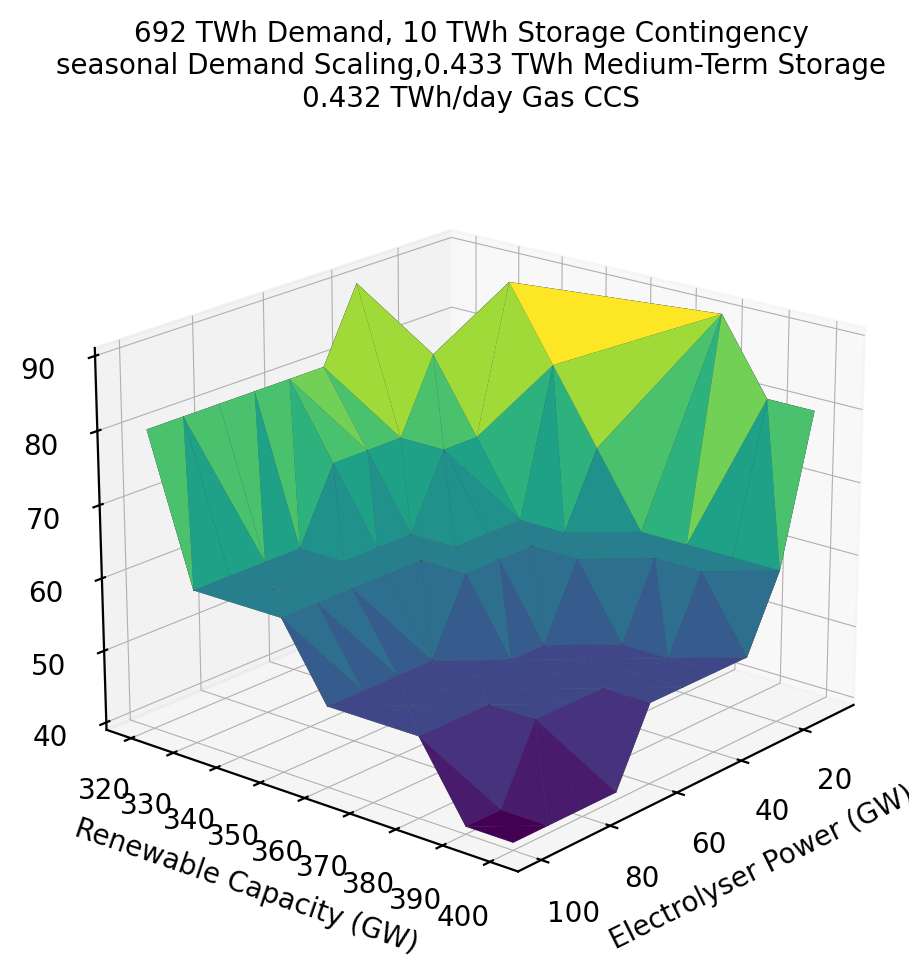

In [14]:
# meshgrid for x and y
X, Y = np.meshgrid(electrolyser_powers, renewable_capacities)

# flatten arrays and filter out NaN values for plot_trisurf
X_flat = X.flatten()
Y_flat = Y.flatten()
Z_flat = Z.flatten()

# create mask to remove NaN values
mask = ~np.isnan(Z_flat)
X_clean = X_flat[mask]
Y_clean = Y_flat[mask]
Z_clean = Z_flat[mask]

# plot the surface using trisurf to handle NaN values
fig = plt.figure(figsize=(6, 5), dpi=200, tight_layout=True)
ax = fig.add_subplot(111, projection="3d")
ax.plot_trisurf(X_clean, Y_clean, Z_clean, color="lightblue", alpha=1.0, edgecolor="black", linewidth=0.1)  # type: ignore[unresolved-attribute]
# ax.plot_trisurf(X1, Y1, Z1, color="lightgreen", alpha=0.6, edgecolor="black", linewidth=0.1)
ax.set_xlabel("Electrolyser Power (GW)")
ax.set_ylabel("Renewable Capacity (GW)")
ax.set_zlabel("Maximum Storage (TWh)")  # type: ignore[unresolved-attribute]
ax.view_init(elev=20, azim=40)  # type: ignore[unresolved-attribute]
ax.plot_trisurf(X_clean, Y_clean, Z_clean, cmap='viridis', edgecolor='none')

# zoom out to make the axis smaller
ax.set_title(
    f"{A.EnergyDemand2050.magnitude:.0f} TWh Demand, {CONTINGENCY_MIN_STORAGE.magnitude} TWh Storage Contingency\n{demand_mode} Demand Scaling,"
    f"{model.medium_storage_capacity} TWh Medium-Term Storage\n{model.gas_ccs_max_daily_energy} TWh/day Gas CCS",
    fontsize=10,
)
plt.tight_layout()
plt.savefig(Path("storage_capacity_surface.png"), dpi=200)
plt.show()

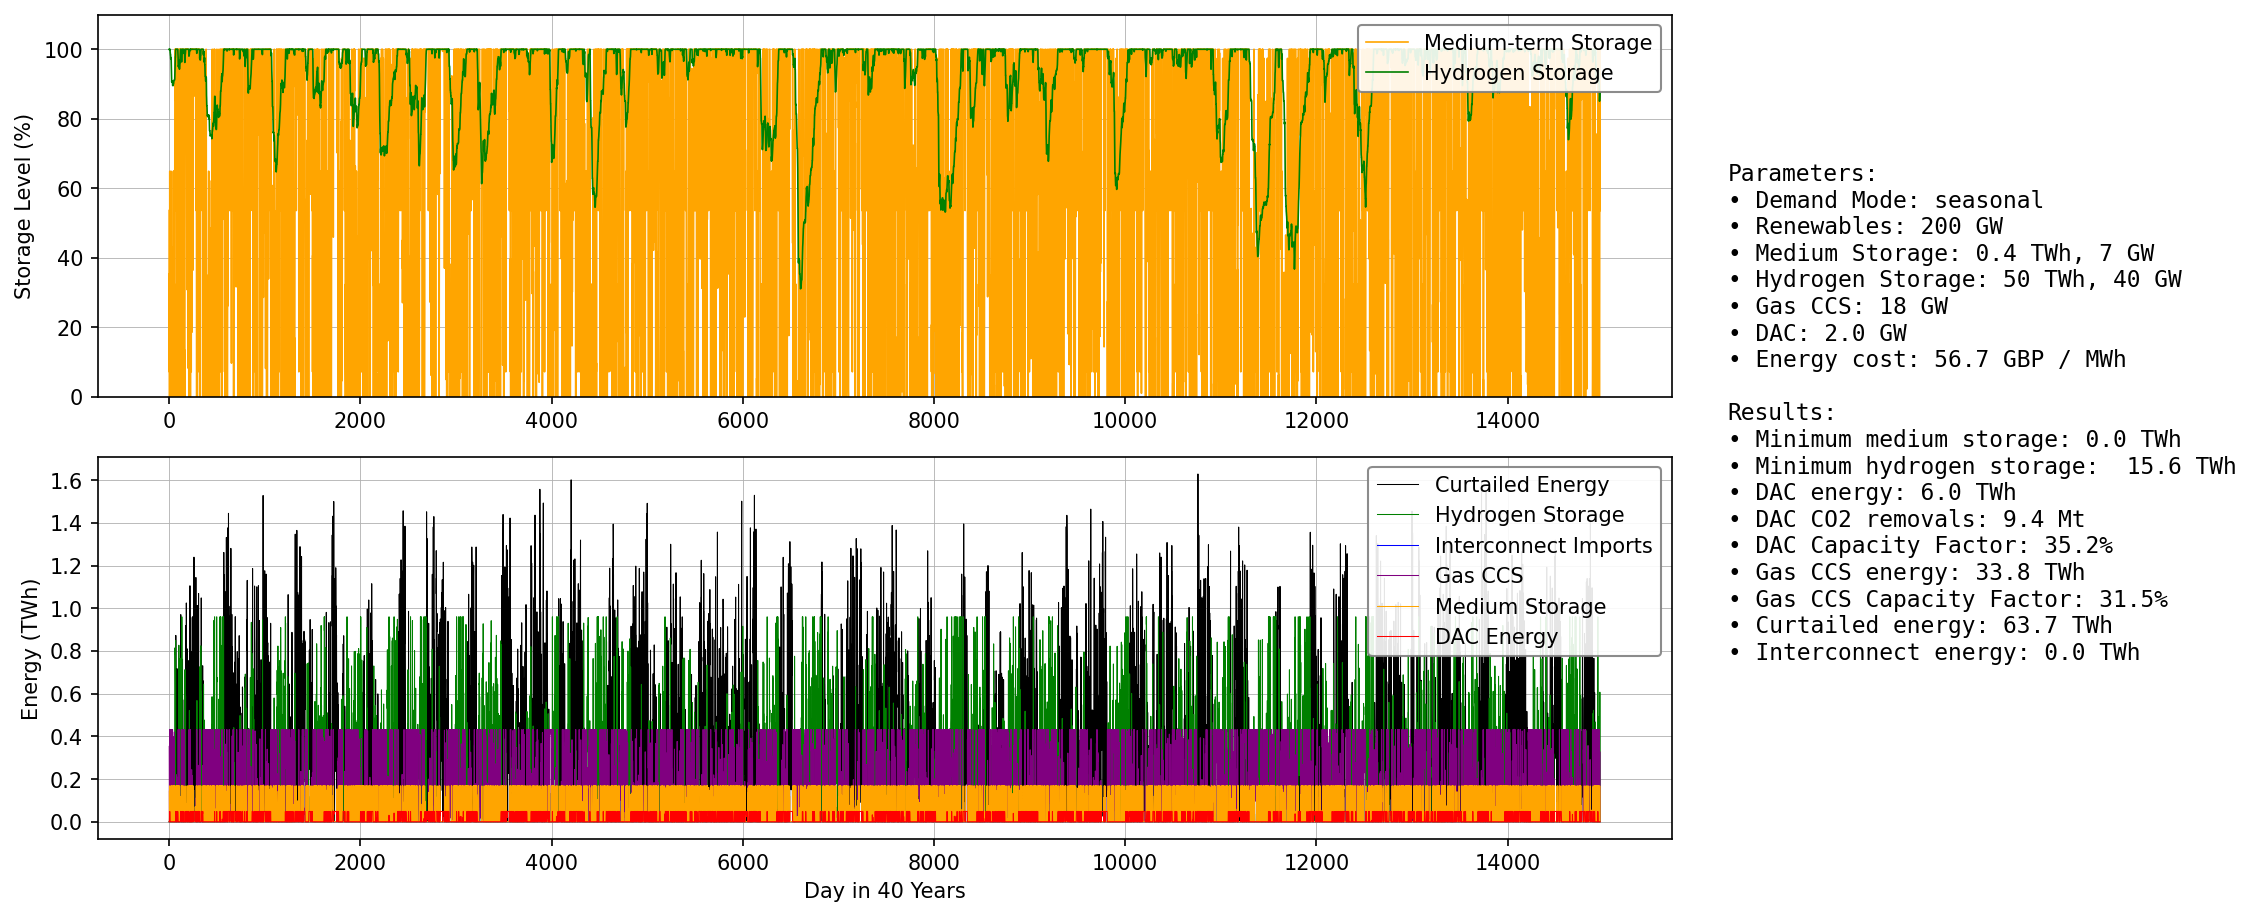

In [20]:
from src.data import renewable_capacity_factors
from src.supply_model import daily_renewables_capacity

renewable_capacity = 200
demand_mode = DemandMode.SEASONAL

A.EnergyDemand2050 = A.CB7EnergyDemand2050
demand_df = demand_model.predicted_demand(mode=demand_mode, average_year=False)

daily_cf = renewable_capacity_factors.get_renewable_capacity_factors(
    source="era5_2024", resample="D"
)
supply = daily_renewables_capacity(renewable_capacity * U.GW, daily_cf)

common_idx = supply.index.intersection(demand_df.index)
supply = supply.reindex(common_idx)
demand = demand_df.reindex(common_idx)

net_supply_df = (supply - demand["demand"]).to_frame(
    name=f"S-D(TWh),Ren={renewable_capacity}GW"
)
df = net_supply_df.reset_index()

model = power_system.PowerSystem(
    renewable_capacity=renewable_capacity * U.GW,
    hydrogen_storage_capacity=50 * U.TWh,
    electrolyser_power=A.HydrogenStorage.Electrolysis.Power,
    dac_capacity=2 * U.GW,
    only_dac_if_hydrogen_storage_full=False,
    medium_storage_capacity=A.MediumTermStorage.Capacity,
    medium_storage_power=A.MediumTermStorage.Power,
)

sim_df = model.run_simulation(df)
results = model.analyze_simulation_results(sim_df)
model.plot_simulation_results(sim_df, results, demand_mode)
